#### **LOAD ALL THE LIBRARIES**

In [41]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

#### **LOAD THE ENV FILE**

In [42]:
load_dotenv()

True

#### **CRETE A LLM  MODEL**

In [43]:
import os
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.6-flash",
    api_key=os.getenv("GEMINI_API_KEY"),
    max_tokens=1000
)

#### **DEFINE STATE**

In [44]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

#### **CREATING THE NODE**

In [45]:
def create_outline(state: BlogState):
    # fetch title
    title = state['title']

    # call LLM to get outline
    prompt = f"Generate a detailed outline for a Blog on the topic: {title}"
    
    # Generate the outline
    outline = llm.invoke(prompt).content

    # Update the state (this was flipped in your code!)
    state['outline'] = outline

    return state

In [46]:
def create_blog(state: BlogState):
    title = state['title']
    outline = state['outline']

    prompt = f"Write a detailed blog on the given title: {title} using the following outline: {outline}"

    content = llm.invoke(prompt).content

    # Update the state
    state['content'] = content

    return state

In [47]:
# Create a Graph
graph = StateGraph(BlogState)

# Create Nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# Add edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# Compile the graph (renamed to workflow to match your video)
workflow = graph.compile()

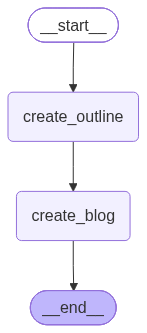

In [48]:
graph.compile()

In [ ]:
# Execute the Graph
initial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': [{'type': 'text', 'text': 'Here is a comprehensive, detailed outline for a blog post on **"The Rise of AI in India."** It is designed to be engaging, informative, and SEO-friendly', 'extras': {'signature': 'ErceCrQeAWkUfRMHEAff39PDGNgyxa5iLBRBd4wup7R3k5Ukkht174Fq/tPb2gG7RCRGYGXzPPKeUM0TRMwTs6mBLw1JMrTRTOvXZ1vxL5WWyFQ7XDvel5/0RpWYkORRxzN7ybF/koc6CqKKhwuaMdHxzBEo/hadUDwDeYQ9abO0/blXHs1auA2Nl/HmkASHMyGNd1/nho96LO2n1hmHlV+0Mo7pOyEBv/EkCJymCm2T09cUhPI81J43Cn0grnIEMKsGiy2sqNeBlFmAWWEox6UpLahSZKXtyZ+RjdwKFgNVEtrLScWsZBRc38DRldZLEqK5jgcLzc/oeAlHLVLGJiGLaV/V+emaAWRBV3P1UevU0DSlMZ+SsTLyWHdTsqnC1JSTi/tqcjk+1rbG0VnzyeBho95/2bhJqO6TD5QuDo9ku/DfHLX2htRp6xs2l/61dnajtpbeHmfdnqPBhej+wI3QI1OxLoxcijjtNOpSX6CWafmHff6zGok22CZJ10hqPP0LuVC1UWEapWXKf4y0n6G72futEZExWbv4t5/gRdt6wOWCc5AZ8D2yVxW3VdCEUUJlVlTq6mkef6S+GRCEBRxesL/mRizCINX8f/0LhQBcUvfdoXUR0odJC2WO0oHXk7lrtf5T6HMtIr7ga34YUOx7vJS6bv2EIqcLpImqTLYC3ahBLfazXfiaRkWXAPzQBFWIlIlpHVCCoQOSHPVETGCp9uUEk9COPmGPqlsKlaUES

In [55]:
# Print the title
print("TITLE:")
print(final_state['title'])

# Print the outline text
print("\nOUTLINE:")
# Access the first item in the list [0], then grab the 'text' value
print(final_state['outline'][0]['text'])

# Print the content text
print("\nCONTENT:")
# Access the first item in the list [0], then grab the 'text' value
print(final_state['content'][0]['text'])

TITLE:
Rise of AI in India

OUTLINE:
Here is a comprehensive, detailed outline for a blog post on **"The Rise of AI in India."** It is designed to be engaging, informative, and SEO-friendly

CONTENT:
Here is a detailed, engaging, and SEO-friendly blog post based on the comprehensive outline for **"The Rise of AI in India."**

---

# The Rise of AI in India:
